# Día 10 · Unidad 11 — Regresión lineal con scikit-learn

**Objetivos de aprendizaje**
- Entender la regresión como problema de encontrar una relación entre variables independientes y una variable dependiente.
- Ajustar una regresión lineal simple y múltiple con `LinearRegression` de scikit-learn.
- Interpretar el coeficiente de determinación ($R^2$), la ordenada en el origen y los coeficientes.
- Ampliar a regresión polinómica con `PolynomialFeatures` y reconocer visualmente el sobreajuste (*overfitting*) y el infraajuste (*underfitting*).

**Duración estimada:** 60-75 minutos.

**Requisitos previos:** pandas y NumPy (Día 7), estadística descriptiva y correlación (Día 9). No hace falta haber usado scikit-learn antes: es la primera vez que aparece en el curso.

## 1. ¿Qué es una regresión?

La regresión busca una relación entre una o varias **variables independientes** (predictoras) y una **variable dependiente** (la que queremos explicar o predecir). Es el mismo concepto estadístico que ya conocéis de un ajuste por mínimos cuadrados en una hoja de cálculo — aquí lo hacemos con código, de forma reproducible y escalable a muchas variables.

Ejemplos actuariales típicos:
- Prima anual en función de la potencia del vehículo y la antigüedad del conductor.
- Importe de un siniestro en función del tipo de vehículo y la provincia.
- Gasto sanitario en función de la edad y el histórico de siniestros.

scikit-learn es la librería estándar de Python para modelos de aprendizaje automático "clásico" (no *deep learning*): expone una interfaz consistente (`.fit()`, `.predict()`, `.score()`) para decenas de algoritmos distintos, algo que veréis también en el resto de la unidad.

## 2. Regresión lineal simple

Partimos de un ejemplo mínimo: el kilometraje anual declarado (en miles de km) de un conjunto de pólizas de auto, y el número de siniestros que tuvieron en el periodo. Son datos de juguete (inventados a mano) para centrarnos en la mecánica de scikit-learn antes de usar un dataset real en el resto del día.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# km_anuales_miles: kilometraje anual declarado, en miles de km
# num_siniestros: numero de siniestros en el periodo observado
km_anuales_miles = np.array([5, 15, 25, 35, 45, 55]).reshape(-1, 1)
num_siniestros = np.array([5, 20, 14, 32, 22, 38])

`reshape(-1, 1)` convierte el array 1D en una matriz de una columna y tantas filas como haga falta (`-1` = "que lo calcule NumPy"). scikit-learn siempre espera que `X` (las variables independientes) sea una matriz 2D, aunque solo haya una columna — es la forma de dejar claro que podría haber varias.

Instanciamos el modelo y lo ajustamos con `.fit(X, y)`:

In [2]:
model = LinearRegression()
model.fit(km_anuales_miles, num_siniestros)

r_sq = model.score(km_anuales_miles, num_siniestros)
print(f"R^2: {r_sq:.3f}")
print(f"Ordenada en el origen (b0): {model.intercept_:.3f}")
print(f"Pendiente (b1): {model.coef_[0]:.3f}")

R^2: 0.716
Ordenada en el origen (b0): 5.633
Pendiente (b1): 0.540


`.score()` devuelve el **coeficiente de determinación** $R^2$: la proporción de la varianza de `y` que explica el modelo (1 = ajuste perfecto, 0 = el modelo no explica nada mejor que la media). `.intercept_` y `.coef_` son los parámetros $b_0$ (ordenada en el origen) y $b_1$ (pendiente) de la recta $y = b_0 + b_1 x$.

Con el modelo ya ajustado, `.predict()` estima `y` para observaciones nuevas:

In [3]:
km_nuevo = np.array([[10]])  # una poliza con 10.000 km/anio declarados
prediccion = model.predict(km_nuevo)
print(f"Siniestros esperados para 10.000 km/anio: {prediccion[0]:.2f}")

Siniestros esperados para 10.000 km/anio: 11.03


> ⚠️ **Error típico**: pasar `X` como array 1D (`km_anuales_miles = np.array([5, 15, 25, ...])`, sin `.reshape(-1, 1)`) lanza `ValueError: Expected 2D array, got 1D array instead`. scikit-learn no adivina si tu array 1D es "una fila con muchas columnas" o "muchas filas con una columna" — hay que decírselo explícitamente.

## 3. Regresión lineal múltiple

En la práctica casi nunca hay una única variable predictora. Con más de una columna en `X`, la mecánica de scikit-learn es idéntica — es la ventaja de su interfaz consistente. Vamos a usar ya el dataset real del proyecto final (`data/raw/polizas_auto_anulacion.csv`) para estimar la prima anual en función de dos variables numéricas: la antigüedad del vehículo y la potencia.

In [4]:
import pandas as pd

polizas = pd.read_csv("../data/raw/polizas_auto_anulacion.csv")

# Nos quedamos con las filas sin nulos en potencia_cv para este ejemplo
# (el tratamiento de esos nulos con un Pipeline llega en el siguiente notebook)
datos_modelo = polizas.dropna(subset=["potencia_cv"])

X_multiple = datos_modelo[["antiguedad_vehiculo", "potencia_cv"]]
y_multiple = datos_modelo["prima_anual"]

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_multiple, y_multiple)

print(f"R^2: {modelo_multiple.score(X_multiple, y_multiple):.3f}")
print(f"Ordenada en el origen: {modelo_multiple.intercept_:.2f}")
for nombre, coef in zip(X_multiple.columns, modelo_multiple.coef_):
    print(f"  coeficiente de {nombre}: {coef:.3f}")

R^2: 0.018
Ordenada en el origen: 204.32
  coeficiente de antiguedad_vehiculo: 5.207
  coeficiente de potencia_cv: 1.180


El $R^2$ aquí es bajo (la prima anual real no depende solo de estas dos variables, y además el dataset tiene un outlier a propósito en `prima_anual` — lo vemos en el siguiente notebook). Lo importante en este punto no es el ajuste, sino la lectura de los coeficientes: cada uno indica cuánto cambia la prima esperada al aumentar esa variable en una unidad, **manteniendo la otra constante**. Con varias variables ya no podemos "verlo" en un único gráfico 2D como en el caso simple.

**Para ti:** añade `edad_conductor` como tercera variable a `X_multiple` y vuelve a ajustar el modelo. ¿Sube o baja el $R^2$? ¿Tiene sentido de negocio el signo del coeficiente de `edad_conductor`?

## 4. Regresión polinómica, y el equilibrio entre infraajuste y sobreajuste

Cuando la relación no es lineal, podemos ampliar `X` con potencias de las variables originales ($x, x^2, x^3, \dots$) y seguir usando `LinearRegression` — el modelo sigue siendo lineal *en los coeficientes*, aunque la curva resultante no lo sea. `PolynomialFeatures` genera esas columnas automáticamente.

In [5]:
from sklearn.preprocessing import PolynomialFeatures

x = np.array([5, 15, 25, 35, 45, 55]).reshape(-1, 1)
y = np.array([5, 20, 14, 32, 22, 38])

transformer = PolynomialFeatures(degree=2, include_bias=False)
x_poly = transformer.fit_transform(x)  # equivalente a .fit(x) + .transform(x)

modelo_poly = LinearRegression().fit(x_poly, y)

print(f"R^2 (grado 2): {modelo_poly.score(x_poly, y):.3f}")
print(f"Coeficientes (b1, b2): {modelo_poly.coef_}")

R^2 (grado 2): 0.718
Coeficientes (b1, b2): [ 0.65785714 -0.00196429]


`fit_transform()` es un atajo que hace `.fit()` seguido de `.transform()` en un solo paso — lo usaréis constantemente a partir de ahora, y es la base de cómo funciona un `Pipeline` (siguiente notebook).

Subir el grado del polinomio siempre mejora (o iguala) el $R^2$ sobre los **mismos datos con los que se entrena** — con 6 puntos y grado alto se puede llegar a un ajuste casi perfecto. Eso no significa que el modelo sea mejor: significa que está memorizando el ruido de esos 6 puntos concretos, no aprendiendo una relación generalizable. Vamos a verlo dividiendo en entrenamiento/prueba, algo que en la vida real es obligatorio y que retomamos en profundidad en el siguiente notebook.

In [6]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
x_amplio = np.linspace(0, 10, 40).reshape(-1, 1)
y_amplio = 2 + 0.5 * x_amplio.ravel() + rng.normal(scale=2.5, size=40)  # relacion ~lineal + ruido

x_train, x_test, y_train, y_test = train_test_split(x_amplio, y_amplio, test_size=0.3, random_state=42)

grados = [1, 2, 15]
for grado in grados:
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)  # ojo: transform, no fit_transform, en el test

    modelo = LinearRegression().fit(x_train_poly, y_train)
    r2_train = modelo.score(x_train_poly, y_train)
    r2_test = modelo.score(x_test_poly, y_test)
    print(f"grado {grado:>2}: R^2 train = {r2_train:.3f}  |  R^2 test = {r2_test:.3f}")

grado  1: R^2 train = 0.353  |  R^2 test = 0.434
grado  2: R^2 train = 0.367  |  R^2 test = 0.426
grado 15: R^2 train = 0.256  |  R^2 test = 0.233


Con grado 1 el $R^2$ de entrenamiento y de prueba son parecidos (la relación real es casi lineal). Con grado 15, el $R^2$ de entrenamiento sube (memoriza) mientras el de prueba empeora o se vuelve inestable: el modelo ha aprendido el ruido concreto de los puntos de entrenamiento, no la relación subyacente. **Esa brecha entre el rendimiento en entrenamiento y en prueba es la señal de alarma del sobreajuste**, y es la razón por la que nunca se evalúa un modelo con los mismos datos con los que se entrenó.

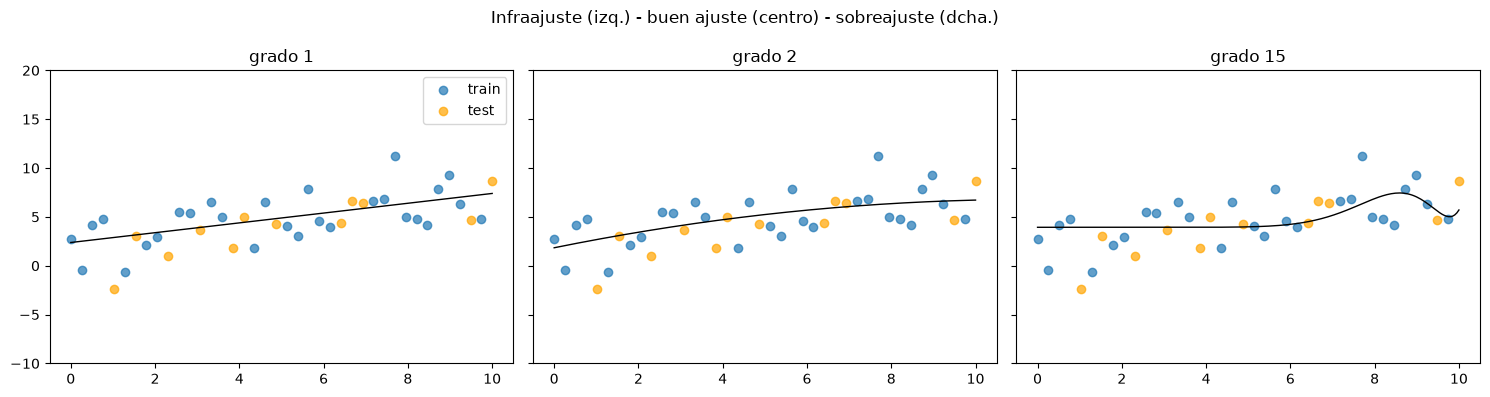

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)

for ax, grado in zip(axes, grados):
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    x_train_poly = poly.fit_transform(x_train)
    modelo = LinearRegression().fit(x_train_poly, y_train)
    y_plot = modelo.predict(poly.transform(x_plot))

    ax.scatter(x_train, y_train, label="train", alpha=0.7)
    ax.scatter(x_test, y_test, label="test", alpha=0.7, color="orange")
    ax.plot(x_plot, y_plot, color="black", linewidth=1)
    ax.set_title(f"grado {grado}")
    ax.set_ylim(-10, 20)

axes[0].legend()
fig.suptitle("Infraajuste (izq.) - buen ajuste (centro) - sobreajuste (dcha.)")
plt.tight_layout()
plt.show()

**Para ti:** cambia `grados = [1, 2, 15]` por `[1, 3, 8]` y repite el gráfico. ¿A partir de qué grado empieza a notarse la curva "persiguiendo" puntos individuales de entrenamiento en vez de seguir la tendencia general?

**Para ti:** en el ejemplo de `modelo_multiple` de la sección 3, calcula el $R^2$ por separado en un `train_test_split` de `datos_modelo`. ¿Es parecido el $R^2$ de train y de test? Con solo dos variables y miles de filas, ¿esperarías mucho riesgo de sobreajuste?

## Resumen

- scikit-learn expone una interfaz consistente para todos sus modelos: `.fit(X, y)` para entrenar, `.predict(X)` para inferir, `.score(X, y)` para evaluar.
- `X` siempre es una matriz 2D (filas = observaciones, columnas = variables), aunque solo haya una variable predictora — de ahí el `.reshape(-1, 1)`.
- `LinearRegression` sirve igual para regresión simple y múltiple; los coeficientes se interpretan "manteniendo el resto de variables constantes".
- `PolynomialFeatures` + `LinearRegression` permite ajustar relaciones no lineales sin cambiar de algoritmo: solo se transforma `X`.
- El $R^2$ de entrenamiento **siempre** mejora o iguala al subir la complejidad del modelo — por eso nunca es una métrica de evaluación fiable por sí sola.
- El sobreajuste se detecta comparando el rendimiento en entrenamiento y en un conjunto de prueba separado (`train_test_split`), nunca evaluando sobre los mismos datos usados para entrenar.
- En el conjunto de test se usa el transformador ya ajustado con el train (`poly.transform(x_test)`), nunca se vuelve a ajustar (`fit_transform`) sobre el test — es el primer aviso de una idea central del siguiente notebook: la fuga de datos (*data leakage*).

**Siguiente:** `02_teoria_pipelines_riesgos_ml.ipynb` — `Pipeline`, `ColumnTransformer`, clasificación de anulación de pólizas, y una sección dedicada a los riesgos del machine learning aplicado (sobreajuste, leakage, variables mal definidas, sesgos).